In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
data = sns.load_dataset('geyser')

print(data)
print(data.shape)

     duration  waiting   kind
0       3.600       79   long
1       1.800       54  short
2       3.333       74   long
3       2.283       62  short
4       4.533       85   long
..        ...      ...    ...
267     4.117       81   long
268     2.150       46  short
269     4.417       90   long
270     1.817       46  short
271     4.467       74   long

[272 rows x 3 columns]
(272, 3)


In [3]:
print(data.isnull().sum())

duration    0
waiting     0
kind        0
dtype: int64


In [5]:
x = data[['waiting', 'duration']].dropna().values

print(x.shape)
print(x[:5])

(272, 2)
[[79.     3.6  ]
 [54.     1.8  ]
 [74.     3.333]
 [62.     2.283]
 [85.     4.533]]


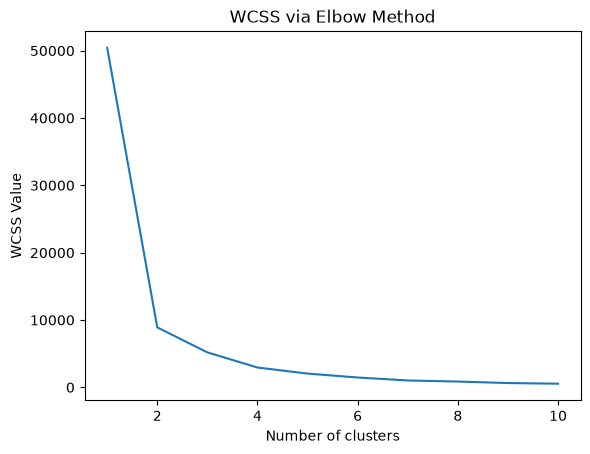

In [6]:
wcss = []

for i in range(1, 11):

    model = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=21,
        n_init=10
    )

    model.fit(x)

    wcss.append(model.inertia_)

plt.plot(range(1, 11), wcss)

plt.title('WCSS via Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS Value')

plt.show()

In [7]:
model = KMeans(
    n_clusters=2,
    init='k-means++',
    random_state=42,
    n_init=10
)

y_means = model.fit_predict(x)

print("Cluster labels:")
print(y_means)

Cluster labels:
[0 1 0 1 0 1 0 0 1 0 1 0 0 1 0 1 1 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1
 0 1 0 0 1 0 1 0 0 1 1 0 1 0 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0
 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 1 0 0 1 0 1 0 0 0
 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 0 0 1 0 1
 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 1
 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 1 0 1 0 1 0 1 0 1 0
 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 1 0 1 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1
 0 0 0 1 0 1 1 0 0 1 0 1 0]


In [8]:
print("Cluster Centers:")
print(model.cluster_centers_)

Cluster Centers:
[[80.28488372  4.29793023]
 [54.75        2.09433   ]]


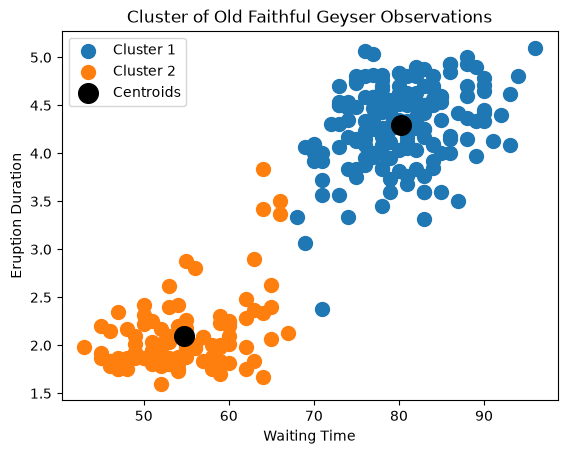

In [9]:
plt.scatter(
    x[y_means == 0, 0],
    x[y_means == 0, 1],
    s=100,
    label='Cluster 1'
)

plt.scatter(
    x[y_means == 1, 0],
    x[y_means == 1, 1],
    s=100,
    label='Cluster 2'
)

plt.scatter(
    model.cluster_centers_[:, 0],
    model.cluster_centers_[:, 1],
    s=200,
    c='black',
    label='Centroids'
)

plt.title('Cluster of Old Faithful Geyser Observations')
plt.xlabel('Waiting Time')
plt.ylabel('Eruption Duration')

plt.legend()
plt.show()